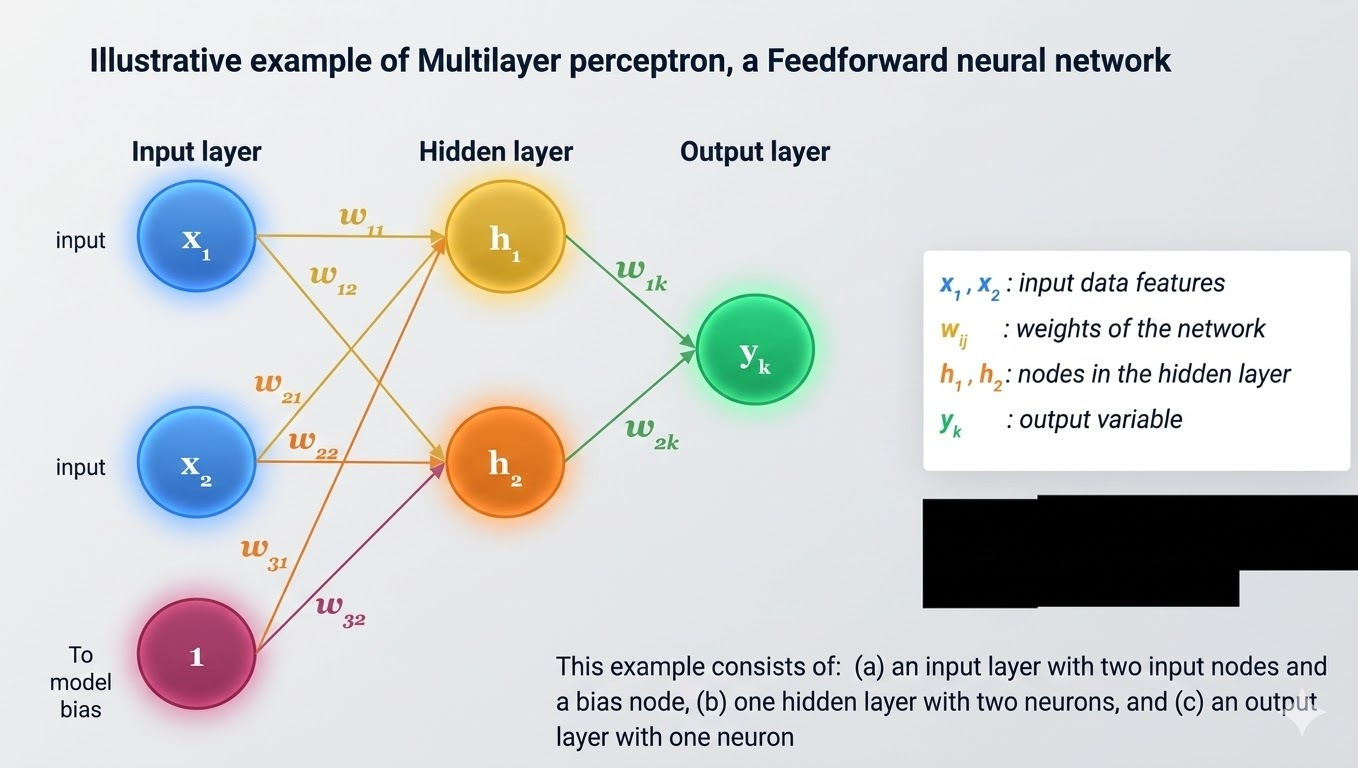

### Import torch libraries

In [ ]:
import torch

### Step 1: Intialize the values

In [ ]:
# 1. Create Leaf Tensors
# We set requires_grad=True to tell PyTorch to track this tensor in the graph
a = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([3.0], requires_grad=True)
c = torch.tensor([10.0], requires_grad=True)

print("--- Step 1: Leaf Tensors ---")
print(f"a: {a.item()}, requires_grad: {a.requires_grad}")
print(f"b: {b.item()}, grad_fn: {b.grad_fn} (Leaf nodes have no grad_fn)")

--- Step 1: Leaf Tensors ---
a: 2.0, requires_grad: True
b: 3.0, grad_fn: None (Leaf nodes have no grad_fn)


### Step 2: Forward Pass Operation

In [ ]:
# 2. Perform Operations (Forward Pass)
# Equation: y = (a * b) + c
# Internally, PyTorch creates two nodes: Multiplier and Adder
x = a * b # a --> 2, b --> 3 (a * b)  ---> + c  (y = a* b + C)
y = x + c

print("\n--- Step 2: Intermediate & Root Tensors ---")
print(f"x (a*b): {x.item()}, grad_fn: {x.grad_fn}") # This is the attribute how PyTorch builds the Computation Graph dynamically.
print(f"y (x+c): {y.item()}, grad_fn: {y.grad_fn}") # This is the attribute how PyTorch builds the Computation Graph dynamically.


--- Step 2: Intermediate & Root Tensors ---
x (a*b): 6.0, grad_fn: <MulBackward0 object at 0x79c229eb4a90>
y (x+c): 16.0, grad_fn: <AddBackward0 object at 0x79c229eb4340>


### Step 3: Display the grad function that is needed

In [ ]:
y.grad_fn.next_functions

((<MulBackward0 at 0x79c204884cd0>, 0),
 (<AccumulateGrad at 0x79c204884820>, 0))

In [ ]:
# 3. Inspecting the graph history
# You can see the operation chain: Add -> Mul
print("\n--- Step 3: Graph Trace ---")
print(f"The operation that created y: {y.grad_fn}")
print(f"The operation that created x: {y.grad_fn.next_functions[0][0]}")



--- Step 3: Graph Trace ---
The operation that created y: <AddBackward0 object at 0x7bff1c714be0>
The operation that created x: <MulBackward0 object at 0x7bff1c895510>


In [ ]:
print(y.grad_fn.next_functions)

((<MulBackward0 object at 0x7bff40f465f0>, 0), (<AccumulateGrad object at 0x7bff40f47c10>, 0))


### Step 4: Perform the backward pass

In [ ]:
# 4. Trigger the Backward Pass
# This calculates gradients for all leaf nodes that have requires_grad=True
y.backward()

### Step 5 : Access the gradients

In [ ]:
# 5. Accessing Gradients
# dy/da = b = 3.0
# dy/db = a = 2.0
# dy/dc = 1.0
print("\n--- Step 4: Gradients (After backward) ---")
print(f"Gradient of y with respect to a (dy/da): {a.grad.item()}")
print(f"Gradient of y with respect to b (dy/db): {b.grad.item()}")
print(f"Gradient of y with respect to c (dy/dc): {c.grad.item()}")


--- Step 4: Gradients (After backward) ---
Gradient of y with respect to a (dy/da): 3.0
Gradient of y with respect to b (dy/db): 2.0
Gradient of y with respect to c (dy/dc): 1.0


### Step 6 : Add dynamic logic to make it work

In [ ]:
# 6. Demonstrating the Dynamic Nature
# We can change the graph logic in real-time
if y > 5:
    z = y * 2
else:
    z = y / 2

print(f"\n Result z: {z.item()}, grad_fn: {z.grad_fn}")


 Result z: 32.0, grad_fn: <MulBackward0 object at 0x7bff40f47c10>
